In [103]:
import pandas as pd
import numpy as np
import re, unicodedata

from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, RandomizedSearchCV

import xgboost as xgb
from tqdm.auto import tqdm

import joblib
import os

In [104]:
ev2 =  pd.read_csv('../../Datasets/amazon_TF-IDF.csv')
ev2.head(3)

,product_title,product_rating,log_total_reviews,log_purchased_last_month,is_sponsored,buy_box_availability,has_coupon,discount_percentage,product_category,brand_cat,...,lsa_5,lsa_6,lsa_7,lsa_8,lsa_9,lsa_10,lsa_11,lsa_12,lsa_13,lsa_14
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,5.883322,0.000000,Sponsored,1,0,0.0,PC Components,OTHER,...,-0.021103,0.004509,-0.020710,0.002470,-0.043854,-0.056647,0.011715,0.001423,-0.018819,0.021984
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,5.624018,0.000000,Sponsored,1,0,0.0,Storage & Memory Cards,OTHER,...,-0.014339,-0.003693,-0.017993,-0.006643,-0.058103,-0.031453,0.012821,0.029994,-0.043295,-0.013305
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,11.523598,10.819798,Organic,0,0,0.0,"Office Supplies, Ink & Toner",HP,...,-0.059286,-0.041266,-0.023047,-0.037955,-0.020370,0.290854,0.089620,-0.106677,-0.213160,0.019634


In [105]:
ev2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7717 entries, 0 to 7716
Data columns (total 36 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   product_title             7717 non-null   object 
 1   product_rating            7717 non-null   float64
 2   log_total_reviews         7717 non-null   float64
 3   log_purchased_last_month  7717 non-null   float64
 4   is_sponsored              7717 non-null   object 
 5   buy_box_availability      7717 non-null   int64  
 6   has_coupon                7717 non-null   int64  
 7   discount_percentage       7717 non-null   float64
 8   product_category          7717 non-null   object 
 9   brand_cat                 7717 non-null   object 
 10  is_high_end               7717 non-null   int64  
 11  spec_ram_gb               532 non-null    float64
 12  spec_storage_gb           658 non-null    float64
 13  spec_screen_inch          994 non-null    float64
 14  spec_pow

In [ ]:
target = 'log_original_price'

ev2.drop(columns=['product_title'], inplace=True)

In [ ]:
# Aseguramos que tenemos el precio original en euros para calcular los rangos
if 'original_price' not in ev2.columns:
    ev2['original_price'] = np.expm1(ev2['log_original_price'])

# Definimos las columnas que queremos usar (Specs + Embeddings + Roles)
# (Excluimos las que vamos a calcular ahora o que son objetivo)
cols_excluded = ['log_original_price', 'original_price', 'product_segment']
features_base = [c for c in ev2.columns if c not in cols_excluded]

# ==============================================================================
# 2. SPLIT TRAIN/TEST (CRÍTICO: HACERLO ANTES DE CALCULAR LÍMITES)
# ==============================================================================
# Dividimos primero para que los umbrales de "Gama Alta" se calculen 
# solo con lo que el modelo "conoce" (Train), simulando el mercado real.

X_temp = ev2.copy()
y_temp = ev2['log_original_price']

train_df, test_df = train_test_split(X_temp, test_size=0.20, random_state=42)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

# ==============================================================================
# 3. CÁLCULO DE UMBRALES (Solo con Train)
# ==============================================================================
def obtener_umbrales_iqr(df):
    umbrales = {}
    for cat in df['product_category'].unique():
        # Filtramos precios válidos para esa categoría
        precios = df[df['product_category'] == cat]['original_price']
        
        if len(precios) > 5: # Solo si hay suficientes datos
            q1 = precios.quantile(0.25)
            q3 = precios.quantile(0.75)
            iqr = q3 - q1
            # Definimos los límites
            limite_baja = q1 # Por debajo de Q1 es "Baja"
            limite_premium = q3 + (1.5 * iqr) # Muy por encima es "Premium"
            
            umbrales[cat] = {'limite_baja': limite_baja, 'limite_premium': limite_premium}
        else:
            # Valores por defecto si la categoría es nueva o vacía
            umbrales[cat] = {'limite_baja': 0, 'limite_premium': 999999}
    return umbrales

print("Calculando gamas de precios del mercado actual...")
dict_umbrales = obtener_umbrales_iqr(train_df)

# ==============================================================================
# 4. APLICACIÓN DE SEGMENTOS
# ==============================================================================
def asignar_segmento(row, umbrales_dict):
    cat = row['product_category']
    precio = row['original_price']
    
    # Si es una categoría desconocida, asumimos Media
    if cat not in umbrales_dict:
        return 'Media'
    
    limites = umbrales_dict[cat]
    
    if precio <= limites['limite_baja']:
        return 'Baja'
    elif precio >= limites['limite_premium']:
        return 'Alta' # O 'Premium'
    else:
        return 'Media'

# Aplicamos la función fila a fila
train_df['product_segment'] = train_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))
test_df['product_segment'] = test_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))

# ==============================================================================
# 5. ONE-HOT ENCODING MANUAL (Tu código integrado)
# ==============================================================================
print("Aplicando One-Hot Encoding...")

# 1. Definimos todas las categóricas (Las tuyas + la nueva de Segmento + Brand)
# Nota: Quitamos 'is_best_seller' si no la tienes en tu df_ready, si la tienes déjala.
categorical_cols = [
    'is_sponsored', 
    'product_category', 
    'spec_resolution_cat', 
    'brand_cat', 
    'buy_box_availability', # Importante si la tienes
    'is_best_seller',    # <--- AÑADIMOS ESTA COLUMNA SI LA TENEMOS
    'segment_iqr'           # <--- AÑADIMOS LA NUEVA COLUMNA DE PRECIO
]

# Filtramos solo las que realmente existen en tu dataframe para evitar errores
valid_cats = [c for c in categorical_cols if c in train_df.columns]

# 2. Aplicamos get_dummies por separado
# (Hacemos esto para no mezclar datos de train y test antes de tiempo)
X_train_encoded = pd.get_dummies(train_df, columns=valid_cats, drop_first=True)
X_test_encoded  = pd.get_dummies(test_df,  columns=valid_cats, drop_first=True)

# 3. ALINEACIÓN DE COLUMNAS (EL PASO MÁS IMPORTANTE)
# Puede que en Train aparezca 'brand_Sony' y en Test no. Esto lo arregla.
# Mantenemos solo las columnas de Train, y si faltan en Test, las pone a 0.
X_train_final, X_test_final = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# 4. Limpieza final de columnas sobrantes (Objetivos y textos)
cols_to_drop = ['log_original_price', 'original_price', 'product_title', 'clean_title', 'clean_title_bert']
# Aseguramos que solo borramos las que existen
cols_to_drop = [c for c in cols_to_drop if c in X_train_final.columns]

X_train_final = X_train_final.drop(columns=cols_to_drop)
X_test_final = X_test_final.drop(columns=cols_to_drop)

y_train = train_df['log_original_price']
y_test  = test_df['log_original_price']

print(f"✅ Encoding completado.")
print(f"Cols Train: {X_train_final.shape[1]}")
print(f"Cols Test:  {X_test_final.shape[1]} (Deben ser iguales)")

Train size: 6173 | Test size: 1544
Calculando gamas de precios del mercado actual...
Aplicando One-Hot Encoding...
✅ Encoding completado.
Cols Train: 114
Cols Test:  114 (Deben ser iguales)


In [22]:
X_train_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 5694 to 7270
Columns: 114 entries, product_rating to segment_iqr_Media
dtypes: bool(86), float64(26), int64(2)
memory usage: 1.9 MB


In [23]:
dtrain_reg = xgb.DMatrix(X_train_final, y_train)
dtest_reg = xgb.DMatrix(X_test_final, y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': ['rmse', 'mae'],
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': 42
}

# ========================================
# PARTE 1: Entrenamiento inicial con barra
# ========================================
print("🚀 Entrenamiento inicial...")

# Callback para barra de progreso
class TqdmCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds):
        self.pbar = tqdm(total=total_rounds, desc="Training")
        self.best_score = float('inf')
    
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        
        # Actualizar métricas cada 50 iteraciones
        if epoch % 50 == 0 or epoch == 0:
            train_rmse = evals_log['train']['rmse'][-1]
            val_rmse = evals_log['val']['rmse'][-1]
            self.pbar.set_postfix({
                'train_rmse': f'{train_rmse:.4f}', 
                'val_rmse': f'{val_rmse:.4f}'
            })
        
        return False
    
    def after_training(self, model):
        self.pbar.close()
        return model

evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
model = xgb.train(
    params,
    dtrain_reg,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False,  # Desactivar verbose
    callbacks=[TqdmCallback(3000)]
)
best_iteration = model.best_iteration
print(f"✅ Mejor iteración: {best_iteration}\n")

# ========================================
# PARTE 2: RandomizedSearchCV con barra
# ========================================
print("🔍 Búsqueda de hiperparámetros...")

param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 5, 10, 50]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iteration,
    tree_method='hist',
    enable_categorical=True,
    verbosity=0  # Silenciar XGBoost
)

# Wrapper para mostrar progreso en RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV as OriginalRandomizedSearchCV
import sklearn.model_selection._validation as val_module

class TqdmRandomizedSearchCV(OriginalRandomizedSearchCV):
    def fit(self, X, y=None, **fit_params):
        # Total de fits = n_iter * cv_folds
        total = self.n_iter * (self.cv if isinstance(self.cv, int) else 5) 
        self.pbar = tqdm(total=total, desc="CV Progress")
        
        # Guardamos la función original del MÓDULO, no de self
        original_fit_and_score = val_module._fit_and_score
        
        def wrapped_fit_and_score(*args, **kwargs):
            result = original_fit_and_score(*args, **kwargs)
            self.pbar.update(1)
            return result
        
        # Reemplazamos temporalmente la función en el módulo
        val_module._fit_and_score = wrapped_fit_and_score
        
        try:
            # Ejecutar el fit original
            result = super().fit(X, y, **fit_params)
        finally:
            # Restauramos la función original siempre, incluso si hay error
            val_module._fit_and_score = original_fit_and_score
            self.pbar.close()
            
        return result

# El resto de tu configuración se mantiene igual
random_search = TqdmRandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)

print(f"\n✅ Búsqueda completada!")
print(f"📊 Mejores parámetros:")
for param, value in random_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n🎯 Mejor RMSE: {(-random_search.best_score_)**0.5:.4f}")


🚀 Entrenamiento inicial...


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

✅ Mejor iteración: 1176

🔍 Búsqueda de hiperparámetros...


CV Progress:   0%|          | 0/250 [00:00<?, ?it/s]


✅ Búsqueda completada!
📊 Mejores parámetros:
   • subsample: 0.6
   • reg_lambda: 1
   • reg_alpha: 0.1
   • min_child_weight: 3
   • max_depth: 7
   • learning_rate: 0.01
   • gamma: 0.1
   • colsample_bytree: 0.8

🎯 Mejor RMSE: 0.4775


In [24]:
best_model = random_search.best_estimator_
print(f"Mejores parámetros: {random_search.best_params_}")

Mejores parámetros: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0.1, 'min_child_weight': 3, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.8}


RMSE: 0.43657051605075453
MAE: 0.3468857340629832
R²: 0.888113448912215


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

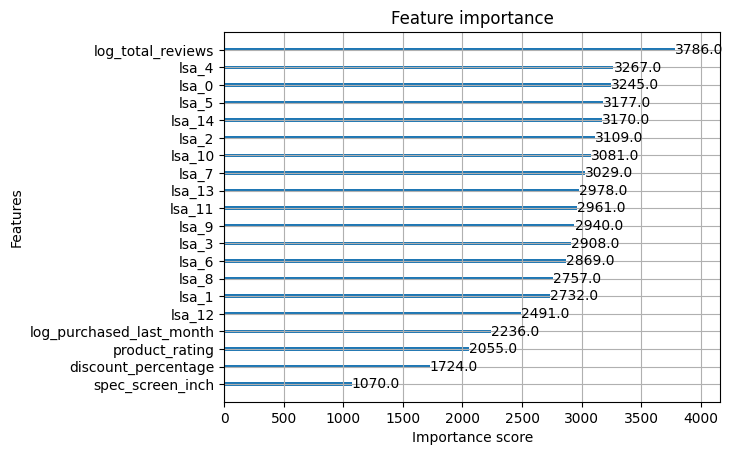

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = best_model.predict(X_test_final)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R²: {r2_score(y_test, y_pred)}")

# Analizar importancia de features
xgb.plot_importance(best_model, max_num_features=20)

In [26]:
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_error

preds = best_model.predict(X_test_final)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(preds)

mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100


df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})


df_residuos['ErrorRelativo%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

for col in [c for c in X_test_final.columns if 'segment' in c]:
    mask = X_test_final[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'ErrorRelativo%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)


print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print(f"R2 Score (Calidad):      {r2_score(y_test_euro, y_pred_euro):.4f}")
# print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)


Segmento segment_iqr_Baja:
   - Error en Euros (MAE): 8.94 €
   - Error en % (MAPE):    35.42 %
--------------------
Segmento segment_iqr_Media:
   - Error en Euros (MAE): 72.14 €
   - Error en % (MAPE):    39.61 %
--------------------
📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      78.09 €
MedAE (Error Típico):   25.58 €
RMSE (Error Penalizado): 203.15 €
MAPE (Error Porcentual): 37.65 %
R2 Score (Calidad):      0.7781


## Modelo sin usar OneHotEncoder (MEJOR QUE EL DE ARRIBA)

In [3]:
ev2_cat =  pd.read_csv('../../Datasets/amazon_TF-IDF.csv')
ev2_cat.head(3)

,product_title,product_rating,log_total_reviews,log_purchased_last_month,is_sponsored,buy_box_availability,has_coupon,discount_percentage,product_category,brand_cat,...,lsa_5,lsa_6,lsa_7,lsa_8,lsa_9,lsa_10,lsa_11,lsa_12,lsa_13,lsa_14
0,OWC 2.0TB Aura Pro X2 (GEN 4) SSD Complete Upg...,4.4,5.883322,0.000000,Sponsored,1,0,0.0,PC Components,OTHER,...,-0.021103,0.004509,-0.020710,0.002470,-0.043854,-0.056647,0.011715,0.001423,-0.018819,0.021984
1,OWC 250GB Aura Pro 6G Flash SSD Upgrade for 20...,4.6,5.624018,0.000000,Sponsored,1,0,0.0,Storage & Memory Cards,OTHER,...,-0.014339,-0.003693,-0.017993,-0.006643,-0.058103,-0.031453,0.012821,0.029994,-0.043295,-0.013305
2,HP 67XL Black High-yield Ink Cartridge | Works...,4.6,11.523598,10.819798,Organic,0,0,0.0,"Office Supplies, Ink & Toner",HP,...,-0.059286,-0.041266,-0.023047,-0.037955,-0.020370,0.290854,0.089620,-0.106677,-0.213160,0.019634


In [4]:
target = 'log_original_price'

In [5]:
ev2_cat.drop(columns=['product_title'], inplace=True)

In [6]:
if 'original_price' not in ev2_cat.columns:
    ev2_cat['original_price'] = np.expm1(ev2_cat['log_original_price'])

# ==============================================================================
# 2. SPLIT TRAIN/TEST
# ==============================================================================
X_temp = ev2_cat.copy()
y_temp = ev2_cat['log_original_price']

# Dividimos antes de nada para evitar Data Leakage en los umbrales
train_df, test_df = train_test_split(X_temp, test_size=0.20, random_state=42)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")

# ==============================================================================
# 3. CÁLCULO DE UMBRALES (Solo con Train)
# ==============================================================================
def obtener_umbrales_iqr(df):
    umbrales = {}
    for cat in df['product_category'].unique():
        precios = df[df['product_category'] == cat]['original_price']
        
        if len(precios) > 5:
            q1 = precios.quantile(0.25)
            q3 = precios.quantile(0.75)
            iqr = q3 - q1
            umbrales[cat] = {
                'limite_baja': q1, 
                'limite_premium': q3 + (1.5 * iqr)
            }
        else:
            umbrales[cat] = {'limite_baja': 0, 'limite_premium': 999999}
    return umbrales

print("Calculando gamas de precios...")
dict_umbrales = obtener_umbrales_iqr(train_df)

# ==============================================================================
# 4. APLICACIÓN DE SEGMENTOS
# ==============================================================================
def asignar_segmento(row, umbrales_dict):
    cat = row['product_category']
    precio = row['original_price']
    
    if cat not in umbrales_dict: return 'Media'
    
    limites = umbrales_dict[cat]
    if precio <= limites['limite_baja']: return 'Baja'
    elif precio >= limites['limite_premium']: return 'Alta'
    else: return 'Media'

train_df['product_segment'] = train_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))
test_df['product_segment'] = test_df.apply(asignar_segmento, axis=1, args=(dict_umbrales,))

# ==============================================================================
# 5. LIMPIEZA FINAL (SIN OHE)
# ==============================================================================
print("Generando X_train y X_test sin One-Hot Encoding...")

# Columnas que definimos como categóricas
categorical_cols = [
    'is_sponsored', 'product_category', 'spec_resolution_cat', 
    'brand_cat', 'buy_box_availability', 'is_best_seller', 'product_segment'
]
# Validamos que existan
valid_cats = [c for c in categorical_cols if c in train_df.columns]

# Definimos qué borrar (Target, Textos crudos, Precios auxiliares)
cols_to_drop = [
    'log_original_price', 'original_price', 
    'product_title', 'clean_title', 'clean_title_bert'
]
# Borramos solo lo que exista
cols_to_drop = [c for c in cols_to_drop if c in train_df.columns]

# Creamos los datasets finales
X_train_final = train_df.drop(columns=cols_to_drop)
X_test_final = test_df.drop(columns=cols_to_drop)

# Paso Importante: Convertir objetos a 'category'
# Esto ayuda a modelos como LightGBM/CatBoost a reconocerlas automáticamente
for col in valid_cats:
    X_train_final[col] = X_train_final[col].astype('category')
    X_test_final[col]  = X_test_final[col].astype('category')

y_train = train_df['log_original_price']
y_test  = test_df['log_original_price']

print(f"✅ Proceso completado.")
print(f"Cols Train: {X_train_final.shape[1]}")
print(f"Ejemplo de columnas: {list(X_train_final.select_dtypes(include=['category']).columns)}")

Train size: 6173 | Test size: 1544
Calculando gamas de precios...
Generando X_train y X_test sin One-Hot Encoding...
✅ Proceso completado.
Cols Train: 35
Ejemplo de columnas: ['is_sponsored', 'buy_box_availability', 'product_category', 'brand_cat', 'spec_resolution_cat', 'is_best_seller', 'product_segment']


In [7]:
dtrain_reg = xgb.DMatrix(X_train_final, y_train, enable_categorical=True)
dtest_reg = xgb.DMatrix(X_test_final, y_test, enable_categorical=True)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': ['rmse', 'mae'],
    'tree_method': 'hist',
    'max_depth': 6,
    'learning_rate': 0.05,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'min_child_weight': 3,
    'gamma': 0,
    'reg_alpha': 0,
    'reg_lambda': 1,
    'random_state': 42
}

# ========================================
# PARTE 1: Entrenamiento inicial con barra
# ========================================
print("🚀 Entrenamiento inicial...")

# Callback para barra de progreso
class TqdmCallback(xgb.callback.TrainingCallback):
    def __init__(self, total_rounds):
        self.pbar = tqdm(total=total_rounds, desc="Training")
        self.best_score = float('inf')
    
    def after_iteration(self, model, epoch, evals_log):
        self.pbar.update(1)
        
        # Actualizar métricas cada 50 iteraciones
        if epoch % 50 == 0 or epoch == 0:
            train_rmse = evals_log['train']['rmse'][-1]
            val_rmse = evals_log['val']['rmse'][-1]
            self.pbar.set_postfix({
                'train_rmse': f'{train_rmse:.4f}', 
                'val_rmse': f'{val_rmse:.4f}'
            })
        
        return False
    
    def after_training(self, model):
        self.pbar.close()
        return model

evals = [(dtrain_reg, 'train'), (dtest_reg, 'val')]
model = xgb.train(
    params,
    dtrain_reg,
    num_boost_round=3000,
    evals=evals,
    early_stopping_rounds=50,
    verbose_eval=False,  # Desactivar verbose
    callbacks=[TqdmCallback(3000)]
)
best_iteration = model.best_iteration
print(f"✅ Mejor iteración: {best_iteration}\n")

# ========================================
# PARTE 2: RandomizedSearchCV con barra
# ========================================
print("🔍 Búsqueda de hiperparámetros...")

param_dist = {
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.5, 1],
    'reg_alpha': [0, 0.1, 1, 10],
    'reg_lambda': [1, 5, 10, 50]
}

xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=best_iteration,
    tree_method='hist',
    enable_categorical=True,
    verbosity=0  # Silenciar XGBoost
)

# Wrapper para mostrar progreso en RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV as OriginalRandomizedSearchCV
import sklearn.model_selection._validation as val_module

class TqdmRandomizedSearchCV(OriginalRandomizedSearchCV):
    def fit(self, X, y=None, **fit_params):
        # Total de fits = n_iter * cv_folds
        total = self.n_iter * (self.cv if isinstance(self.cv, int) else 5) 
        self.pbar = tqdm(total=total, desc="CV Progress")
        
        # Guardamos la función original del MÓDULO, no de self
        original_fit_and_score = val_module._fit_and_score
        
        def wrapped_fit_and_score(*args, **kwargs):
            result = original_fit_and_score(*args, **kwargs)
            self.pbar.update(1)
            return result
        
        # Reemplazamos temporalmente la función en el módulo
        val_module._fit_and_score = wrapped_fit_and_score
        
        try:
            # Ejecutar el fit original
            result = super().fit(X, y, **fit_params)
        finally:
            # Restauramos la función original siempre, incluso si hay error
            val_module._fit_and_score = original_fit_and_score
            self.pbar.close()
            
        return result

# El resto de tu configuración se mantiene igual
random_search = TqdmRandomizedSearchCV(
    xgb_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=0,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)

print(f"\n✅ Búsqueda completada!")
print(f"📊 Mejores parámetros:")
for param, value in random_search.best_params_.items():
    print(f"   • {param}: {value}")
print(f"\n🎯 Mejor RMSE: {(-random_search.best_score_)**0.5:.4f}")


🚀 Entrenamiento inicial...


Training:   0%|          | 0/3000 [00:00<?, ?it/s]

✅ Mejor iteración: 615

🔍 Búsqueda de hiperparámetros...


CV Progress:   0%|          | 0/250 [00:00<?, ?it/s]


✅ Búsqueda completada!
📊 Mejores parámetros:
   • subsample: 0.8
   • reg_lambda: 5
   • reg_alpha: 0
   • min_child_weight: 5
   • max_depth: 7
   • learning_rate: 0.05
   • gamma: 0.1
   • colsample_bytree: 0.6

🎯 Mejor RMSE: 0.4616


In [9]:
folder_path = 'Modelos'
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"📁 Carpeta '{folder_path}' creada.")

best_model = random_search.best_estimator_

model_2_path = os.path.join(folder_path, 'xgb_TF-IDF.json')
best_model.save_model(model_2_path)

print(f"Mejores parámetros: {random_search.best_params_}")
print(f"💾 Mejor modelo guardado en: {model_2_path}")

📁 Carpeta 'Modelos' creada.
Mejores parámetros: {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'min_child_weight': 5, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.6}
💾 Mejor modelo guardado en: Modelos\xgb_TF-IDF.json


In [101]:
# Creamos un diccionario con los Dtypes y las Categorías exactas
metadata = {
    'dtypes': X_train_final.dtypes,
    'columns': X_train_final.columns.tolist(),
    'categories': {}
}

# Guardamos la lista de categorías para cada columna categórica
# Esto es vital para que "Dell" sea siempre "Dell" y no un número aleatorio
for col in X_train_final.select_dtypes(['category']).columns:
    metadata['categories'][col] = X_train_final[col].cat.categories

# Guardamos el archivo en tu carpeta de modelos
joblib.dump(metadata, 'Modelos/metadata_entrenamiento_TF-IDF.pkl')
print("✅ Metadatos guardados: Ahora puedes predecir en cualquier notebook.")

✅ Metadatos guardados: Ahora puedes predecir en cualquier notebook.


RMSE: 0.425048477410307
MAE: 0.33461458477429096
R²: 0.8939413701517029


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

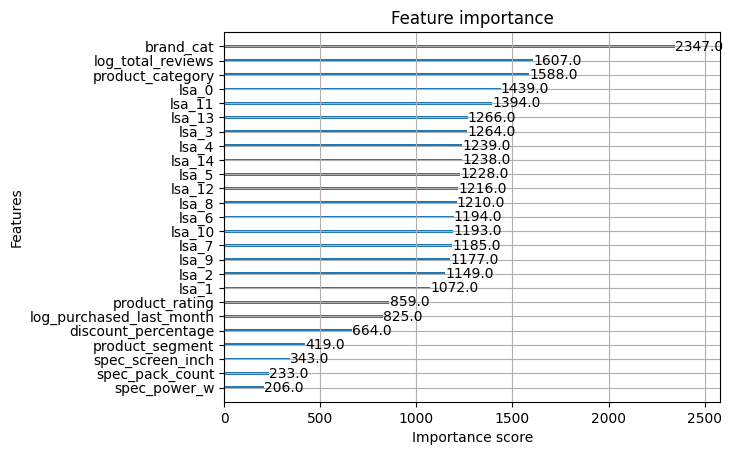

In [107]:
y_pred = best_model.predict(X_test_final)

print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")
print(f"R²: {r2_score(y_test, y_pred)}")

# Analizar importancia de features
xgb.plot_importance(best_model, max_num_features=25)

In [11]:
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_error

preds = best_model.predict(X_test_final)
y_test_euro = np.expm1(y_test)
y_pred_euro = np.expm1(preds)

mae = mean_absolute_error(y_test_euro, y_pred_euro)
rmse = np.sqrt(mean_squared_error(y_test_euro, y_pred_euro))
medae = median_absolute_error(y_test_euro, y_pred_euro)
mape = np.mean(np.abs((y_test_euro - y_pred_euro) / y_test_euro)) * 100


df_residuos = pd.DataFrame({
    'Real': y_test_euro,
    'Pred': y_pred_euro,
    'Error_Abs': np.abs(y_test_euro - y_pred_euro)
})


df_residuos['ErrorRelativo%'] = (df_residuos['Error_Abs'] / df_residuos['Real']) * 100

for col in [c for c in X_test_final.columns if 'segment' in c]:
    mask = X_test_final[col] == 1
    error_rel_seg = df_residuos.loc[mask, 'ErrorRelativo%'].mean()
    mae_seg = df_residuos.loc[mask, 'Error_Abs'].mean()
    print(f"Segmento {col}:")
    print(f"   - Error en Euros (MAE): {mae_seg:.2f} €")
    print(f"   - Error en % (MAPE):    {error_rel_seg:.2f} %")
    print("-" * 20)


print("📊 MÉTRICAS DE RENDIMIENTO (EUROS)")
print(f"MAE (Error Medio):      {mae:.2f} €")
print(f"MedAE (Error Típico):   {medae:.2f} €")
print(f"RMSE (Error Penalizado): {rmse:.2f} €")
print(f"MAPE (Error Porcentual): {mape:.2f} %")
print(f"R2 Score (Calidad):      {r2_score(y_test_euro, y_pred_euro):.4f}")
# print(f"R2 CV (Estabilidad):     {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("="*40)


Segmento product_segment:
   - Error en Euros (MAE): nan €
   - Error en % (MAPE):    nan %
--------------------
📊 MÉTRICAS DE RENDIMIENTO (EUROS)
MAE (Error Medio):      74.59 €
MedAE (Error Típico):   24.00 €
RMSE (Error Penalizado): 196.69 €
MAPE (Error Porcentual): 36.34 %
R2 Score (Calidad):      0.7920
